In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_excel("FinTech_ChainAudit.xlsx")

In [3]:
df.head()

,Transaction_ID,Date,Wallet_Type,Tran_Type,Blockchain,Amount,Gas_Fee_USD,Customer_Type,Region,Processing_Time_sec,Fraud_Risk_Score,Compliance_Status,Marketing_Campaign,Number_of_Active_Customers,Daily_Revenue_USD,Sales
0,TXN100002,2025-07-22,Customer,Swap,BSC,20555.75,32.61,VIP,America,203.0,38.98,Pass,Yes,929.0,12870.12,24666.9
1,TXN100003,2025-12-27,NaN,Staking,Solana,25571.60,16.49,Institutional,Europe,152.0,56.57,Pass,No,519.0,5099.70,30685.92
2,TXN100004,2025-07-27,Operational,DeFi,Polygon,40219.77,39.93,Retail,Europe,27.0,82.62,Review,Yes,2002.0,22341.17,48263.724
3,TXN100005,2025-08-27,Customer,saving,Polygon,44989.59,18.03,VIP,Europe,177.0,1.05,Pass,No,3205.0,31676.08,-5000
4,TXN100006,2025-12-16,Treasury,DeFi,Solana,NaN,77.33,Institutional,Middle East,202.0,29.83,Review,No,3439.0,24182.19,NaN


In [4]:
df.tail()

,Transaction_ID,Date,Wallet_Type,Tran_Type,Blockchain,Amount,Gas_Fee_USD,Customer_Type,Region,Processing_Time_sec,Fraud_Risk_Score,Compliance_Status,Marketing_Campaign,Number_of_Active_Customers,Daily_Revenue_USD,Sales
1996,TXN101998,2025-02-20,Employee,Staking,Polygon,29301.51,92.99,Retail,America,181.0,94.83,Fail,No,820.0,3953.46,35161.812
1997,TXN101999,2025-02-21,Employee,DeFi,Ethereum,42861.13,44.11,VIP,Middle East,222.0,39.01,Review,No,4650.0,36834.23,51433.356
1998,TXN102000,2025-08-14,Customer,NFT,Solana,33225.74,82.92,Retail,Asia,67.0,61.01,Fail,Yes,1856.0,26083.71,39870.888
1999,TXN102001,2025-09-11,Employee,NFT,Polygon,30977.11,100.98,VIP,America,255.0,73.39,Pass,No,2633.0,23772.50,37172.532
2000,TXN100002,2025-07-22,Customer,Swap,BSC,20555.75,32.61,VIP,America,203.0,38.98,Pass,Yes,929.0,12870.12,24666.9


In [5]:
df.shape

(2001, 16)

In [6]:
df.columns

Index(['Transaction_ID', 'Date', 'Wallet_Type', 'Tran_Type', 'Blockchain',
       'Amount ', 'Gas_Fee_USD', 'Customer_Type', 'Region',
       'Processing_Time_sec', 'Fraud_Risk_Score', 'Compliance_Status',
       'Marketing_Campaign', 'Number_of_Active_Customers', 'Daily_Revenue_USD',
       'Sales'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2001 entries, 0 to 2000
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Transaction_ID              1996 non-null   object 
 1   Date                        1982 non-null   object 
 2   Wallet_Type                 1922 non-null   object 
 3   Tran_Type                   1975 non-null   object 
 4   Blockchain                  1983 non-null   object 
 5   Amount                      1990 non-null   float64
 6   Gas_Fee_USD                 1975 non-null   float64
 7   Customer_Type               1981 non-null   object 
 8   Region                      1974 non-null   object 
 9   Processing_Time_sec         1989 non-null   float64
 10  Fraud_Risk_Score            1986 non-null   float64
 11  Compliance_Status           1972 non-null   object 
 12  Marketing_Campaign          1992 non-null   object 
 13  Number_of_Active_Customers  1981 

In [8]:
df.describe()

,Amount,Gas_Fee_USD,Processing_Time_sec,Fraud_Risk_Score,Number_of_Active_Customers,Daily_Revenue_USD
count,1990.000000,1975.000000,1989.000000,1986.000000,1981.000000,1987.000000
mean,24990.586317,59.411241,153.158371,48.763243,2552.363958,22372.492652
std,14346.120987,35.264629,85.973187,28.973853,1425.366197,10412.518021
min,-15000.000000,0.650000,5.000000,0.060000,51.000000,235.680000
25%,12187.292500,27.960000,79.000000,23.630000,1353.000000,14403.990000
50%,24819.780000,58.970000,154.000000,47.885000,2549.000000,22386.230000
75%,37376.755000,90.200000,226.000000,73.217500,3780.000000,30141.950000
max,49979.940000,119.970000,300.000000,99.900000,6676.000000,50623.470000


In [9]:
df.describe(include="all")

,Transaction_ID,Date,Wallet_Type,Tran_Type,Blockchain,Amount,Gas_Fee_USD,Customer_Type,Region,Processing_Time_sec,Fraud_Risk_Score,Compliance_Status,Marketing_Campaign,Number_of_Active_Customers,Daily_Revenue_USD,Sales
count,1996,1982,1922,1975,1983,1990.000000,1975.000000,1981,1974,1989.000000,1986.000000,1972,1992,1981.000000,1987.000000,1991.0
unique,1995,365,5,8,4,NaN,NaN,3,4,NaN,NaN,3,2,NaN,NaN,1988.0
top,TXN100002,2025-03-06,Employee,Swap,BSC,NaN,NaN,VIP,America,NaN,NaN,Pass,Yes,NaN,NaN,24666.9
freq,2,15,513,307,546,NaN,NaN,675,507,NaN,NaN,665,1002,NaN,NaN,2.0
mean,NaN,NaN,NaN,NaN,NaN,24990.586317,59.411241,NaN,NaN,153.158371,48.763243,NaN,NaN,2552.363958,22372.492652,NaN
std,NaN,NaN,NaN,NaN,NaN,14346.120987,35.264629,NaN,NaN,85.973187,28.973853,NaN,NaN,1425.366197,10412.518021,NaN
min,NaN,NaN,NaN,NaN,NaN,-15000.000000,0.650000,NaN,NaN,5.000000,0.060000,NaN,NaN,51.000000,235.680000,NaN
25%,NaN,NaN,NaN,NaN,NaN,12187.292500,27.960000,NaN,NaN,79.000000,23.630000,NaN,NaN,1353.000000,14403.990000,NaN
50%,NaN,NaN,NaN,NaN,NaN,24819.780000,58.970000,NaN,NaN,154.000000,47.885000,NaN,NaN,2549.000000,22386.230000,NaN
75%,NaN,NaN,NaN,NaN,NaN,37376.755000,90.200000,NaN,NaN,226.000000,73.217500,NaN,NaN,3780.000000,30141.950000,NaN


In [10]:
df["Wallet_Type"].unique()

array(['Customer', nan, 'Operational', 'Treasury', 150, 'Employee'],
      dtype=object)

In [11]:
df.isnull().sum()

Transaction_ID                 5
Date                          19
Wallet_Type                   79
Tran_Type                     26
Blockchain                    18
Amount                        11
Gas_Fee_USD                   26
Customer_Type                 20
Region                        27
Processing_Time_sec           12
Fraud_Risk_Score              15
Compliance_Status             29
Marketing_Campaign             9
Number_of_Active_Customers    20
Daily_Revenue_USD             14
Sales                         10
dtype: int64

In [12]:
(df.isnull().sum() / len(df)) * 100

Transaction_ID                0.249875
Date                          0.949525
Wallet_Type                   3.948026
Tran_Type                     1.299350
Blockchain                    0.899550
Amount                        0.549725
Gas_Fee_USD                   1.299350
Customer_Type                 0.999500
Region                        1.349325
Processing_Time_sec           0.599700
Fraud_Risk_Score              0.749625
Compliance_Status             1.449275
Marketing_Campaign            0.449775
Number_of_Active_Customers    0.999500
Daily_Revenue_USD             0.699650
Sales                         0.499750
dtype: float64

In [14]:
df[df.select_dtypes(include="number").columns] = df.select_dtypes(include="number").fillna(df.select_dtypes(include="number").mean())

In [15]:
df[df.select_dtypes(include="object").columns] = df.select_dtypes(include="object").fillna("Unknown")

In [16]:
df.isnull().sum()

Transaction_ID                0
Date                          0
Wallet_Type                   0
Tran_Type                     0
Blockchain                    0
Amount                        0
Gas_Fee_USD                   0
Customer_Type                 0
Region                        0
Processing_Time_sec           0
Fraud_Risk_Score              0
Compliance_Status             0
Marketing_Campaign            0
Number_of_Active_Customers    0
Daily_Revenue_USD             0
Sales                         0
dtype: int64

In [17]:
df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")

In [18]:
df["Sales"] = df["Sales"].fillna(df["Sales"].median())

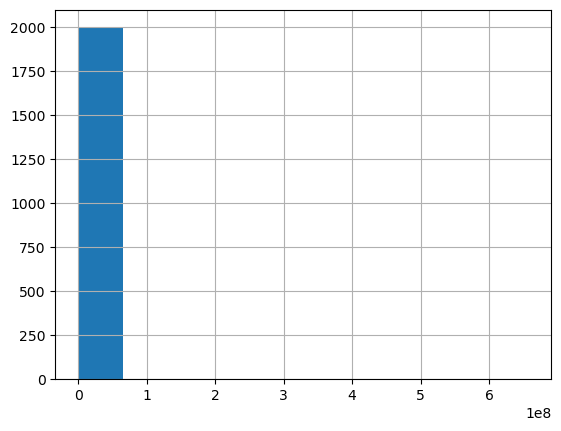

In [19]:
df["Sales"].hist()

plt.show()

In [20]:
df = df.apply(lambda x: pd.to_numeric(x, errors="ignore"))

In [22]:
df[df.select_dtypes(include="number").columns] = df.select_dtypes(include="number").fillna(df.select_dtypes(include="number").median())

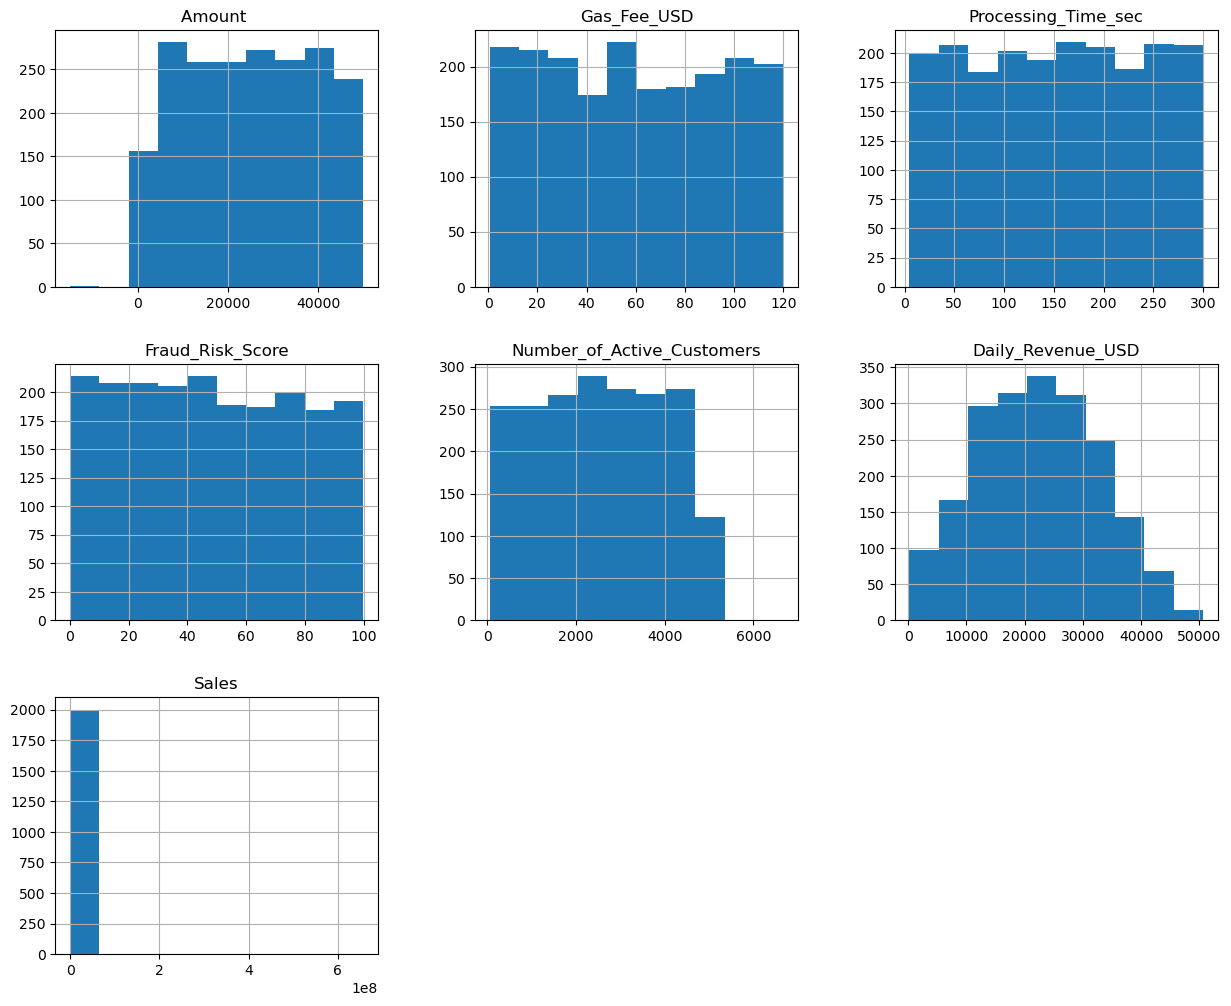

In [23]:
df.select_dtypes(include="number").hist(figsize=(15, 12))
plt.show()

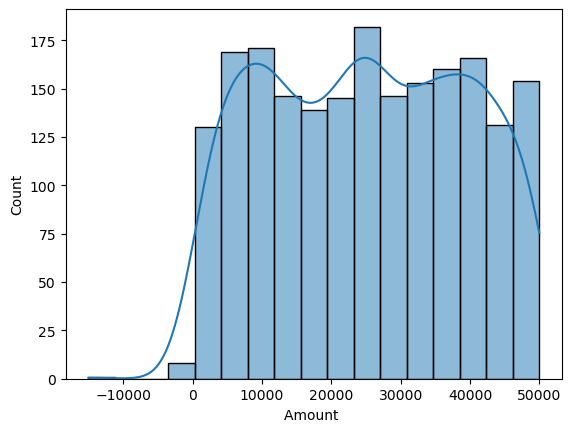

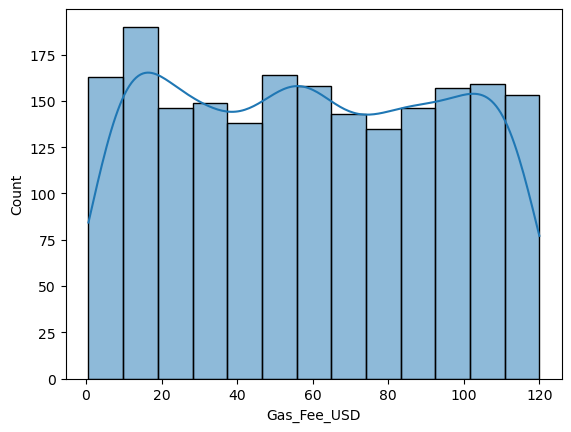

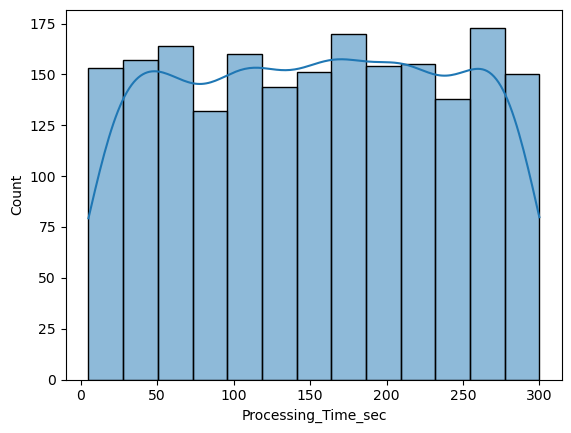

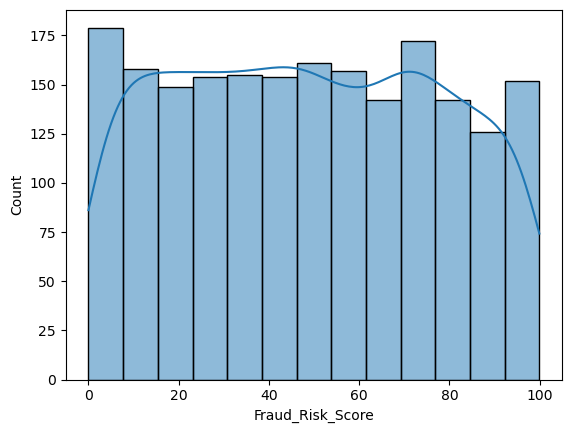

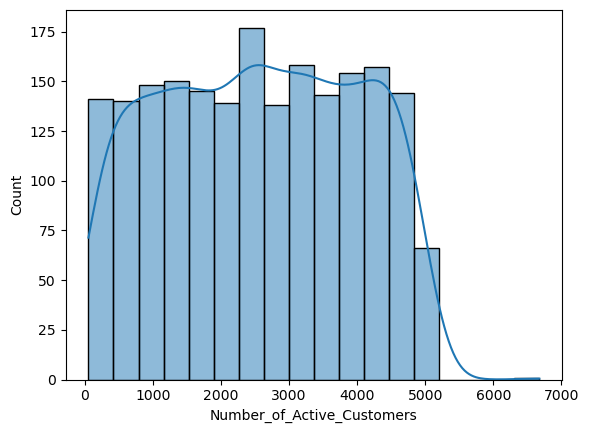

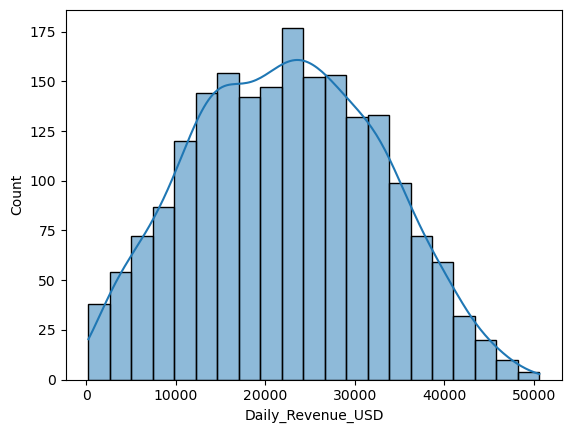

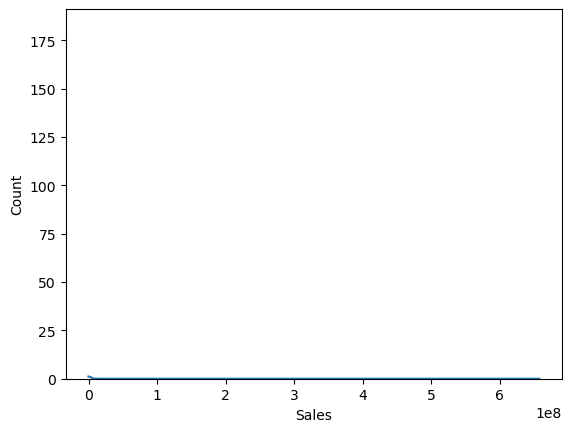

In [24]:
for column in df.select_dtypes(include="number").columns:
    sns.histplot(df[column], kde=True)
    plt.show()

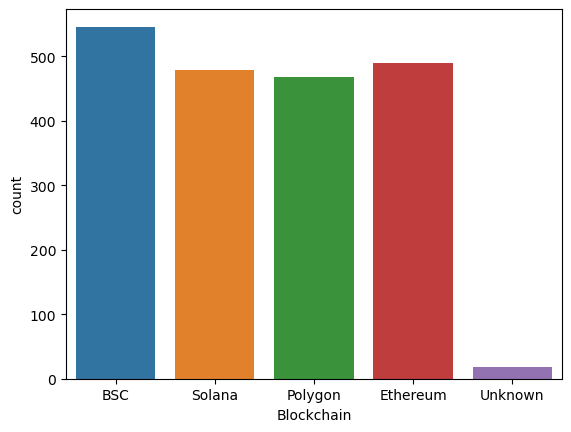

In [36]:
sns.countplot(x="Blockchain", data=df)

plt.show()

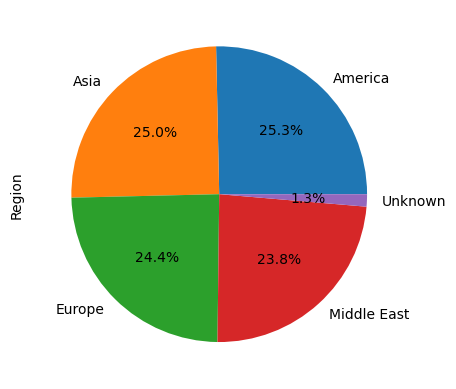

In [26]:
df["Region"].value_counts().plot.pie(autopct="%1.1f%%")
plt.show()

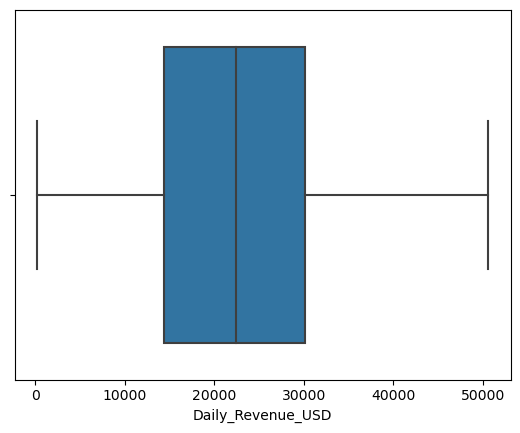

In [27]:
sns.boxplot(x=df["Daily_Revenue_USD"])

plt.show()

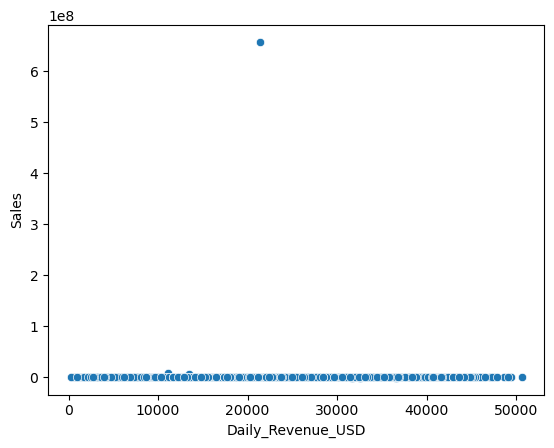

In [28]:
sns.scatterplot(
    x="Daily_Revenue_USD",
    y="Sales",
    data=df
)

plt.show()

In [29]:
df.select_dtypes(include="number").corr()

,Amount,Gas_Fee_USD,Processing_Time_sec,Fraud_Risk_Score,Number_of_Active_Customers,Daily_Revenue_USD,Sales
Amount,1.000000,0.025199,0.039456,0.023433,0.014380,0.238046,0.014842
Gas_Fee_USD,0.025199,1.000000,-0.014022,-0.013304,-0.019980,-0.073515,-0.021662
Processing_Time_sec,0.039456,-0.014022,1.000000,0.026082,-0.009885,-0.002356,0.017769
Fraud_Risk_Score,0.023433,-0.013304,0.026082,1.000000,0.010349,-0.004446,-0.002609
Number_of_Active_Customers,0.014380,-0.019980,-0.009885,0.010349,1.000000,0.837843,-0.003579
Daily_Revenue_USD,0.238046,-0.073515,-0.002356,-0.004446,0.837843,1.000000,-0.002432
Sales,0.014842,-0.021662,0.017769,-0.002609,-0.003579,-0.002432,1.000000


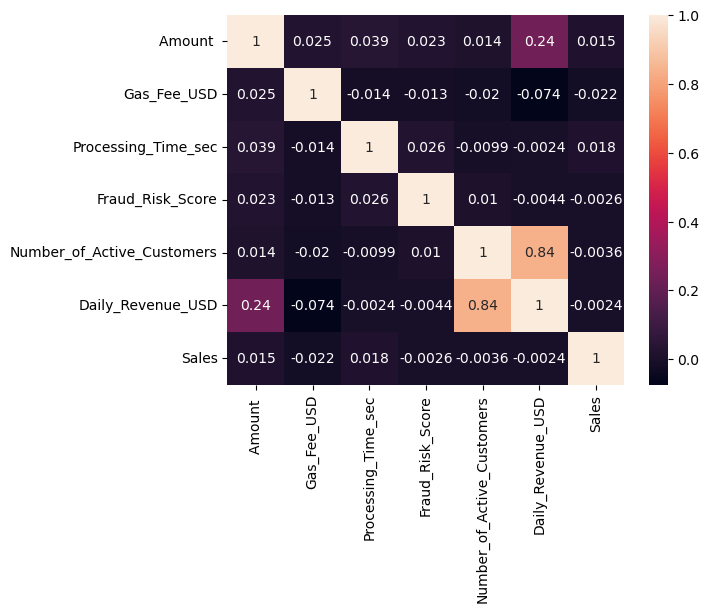

In [30]:
correlation = df.select_dtypes(include="number").corr()

sns.heatmap(correlation, annot=True)

plt.show()

In [31]:
df.columns = df.columns.str.strip()

In [32]:
X = df[[
    "Amount",
    "Gas_Fee_USD",
    "Daily_Revenue_USD"
]]

In [33]:
y = df["Sales"]

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [35]:
model = RandomForestRegressor(random_state=42)

In [37]:
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [38]:
predictions = model.predict(X_test)

In [39]:
mean_absolute_error(y_test, predictions)

1657744.181877806

In [40]:
mean_squared_error(y_test, predictions)

1078537594096425.5

In [41]:
np.sqrt(mean_squared_error(y_test, predictions))

32841096.115940247

In [42]:
r2_score(y_test, predictions)

-0.002523093510321095

In [44]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance

,Feature,Importance
0,Amount,0.502107
1,Gas_Fee_USD,0.472089
2,Daily_Revenue_USD,0.025803


## Interpretation
The Random Forest Regression model was used to predict the Sales values based on the selected independent variables (Amount, Gas_Fee_USD, and Daily_Revenue_USD). The model's performance was evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score. A lower MAE, MSE, and RMSE indicate better prediction accuracy, while a higher R² Score indicates that the model explains a larger proportion of the variation in Sales. Unlike Linear Regression, Random Forest does not provide regression coefficients. Instead, it calculates Feature Importance, which shows the relative contribution of each predictor in estimating Sales. Overall, Random Forest Regression is capable of capturing complex and non-linear relationships between the variables, often providing more accurate predictions than a single Decision Tree or Linear Regression.